Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_1.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectogram\Bus\Image_1.png
Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_10.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectogram\Bus\Image_10.png
Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_100.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectogram\Bus\Image_100.png
Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_11.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectogram\Bus\Image_11.png
Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_12.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectogram\Bus\Image_12.png
Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_13.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectogr

KeyboardInterrupt: 

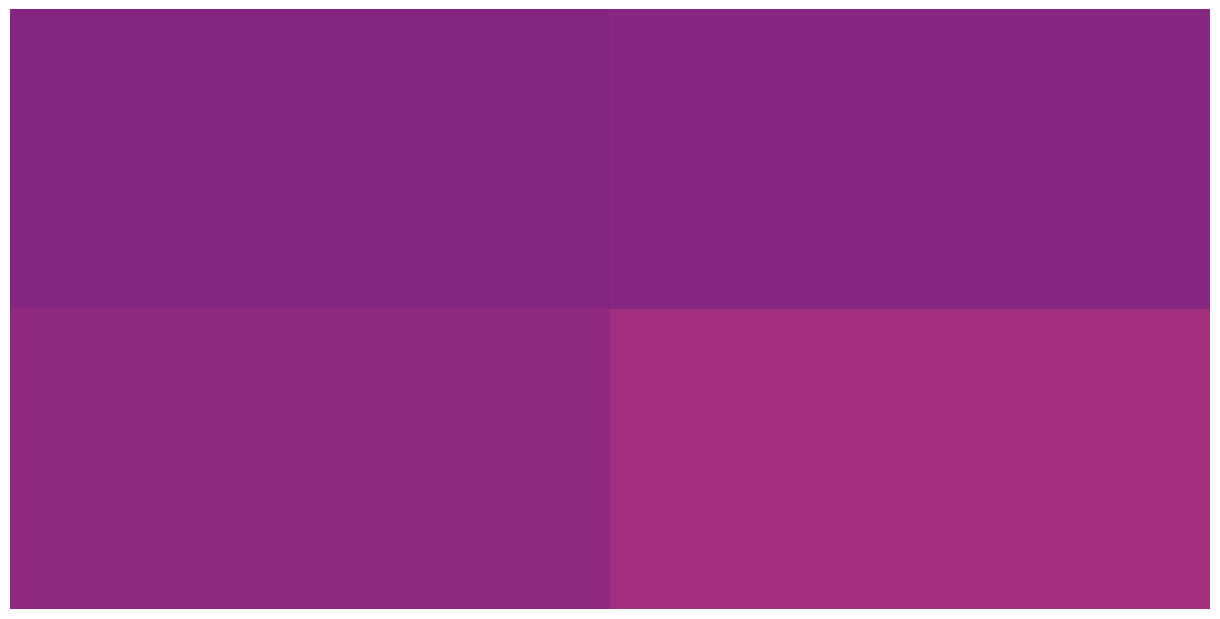

In [2]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def create_spectrogram(audio_path, output_path, figsize=(12, 6), dpi=100):
    """
    Create and save a spectrogram from an audio file (without axes or labels).
    
    Args:
        audio_path (str): Path to input audio file
        output_path (str): Path to save spectrogram image
        figsize (tuple): Figure size (width, height) in inches
        dpi (int): Dots per inch for output image
    """
    try:
        # Load audio file
        y, sr = librosa.load(audio_path)
        
        # Perform STFT
        stft = np.abs(librosa.stft(y))
        
        # Convert to dB scale
        stft_db = librosa.amplitude_to_db(stft, ref=np.max)
        
        # Create the spectrogram plot
        plt.figure(figsize=figsize, frameon=False)
        ax = plt.Axes(plt.gcf(), [0., 0., 1., 1.])  # Full figure area 
        # ax.set_ylim(3500, 4000) # Only focus on the audible spectrum in the spectrum
        ax.set_axis_off()  # Turn off all axis decorations
        plt.gcf().add_axes(ax)
        
        # Display spectrogram without any decorations
        librosa.display.specshow(stft_db, sr=sr, cmap='magma')
        
        # Save the spectrogram (without borders/whitespace)
        plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=dpi)
        plt.close()
        
    except Exception as e:
        print(f"Error processing {audio_path}: {str(e)}")

def process_dataset(input_root, output_root):
    """
    Process all WAV files in a dataset to create spectrograms.
    
    Args:
        input_root (str): Root directory of the audio dataset
        output_root (str): Root directory to save spectrograms (will mirror input structure)
    """
    input_path = Path(input_root)
    output_path = Path(output_root)
    
    # Create output root if it doesn't exist
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Count processed files
    total_files = 0
    
    # Walk through the directory structure
    for root, dirs, files in os.walk(input_path):
        # Get relative path to maintain structure
        relative_path = Path(root).relative_to(input_path)
        current_output_dir = output_path / relative_path
        
        # Create corresponding output directory
        current_output_dir.mkdir(parents=True, exist_ok=True)
        
        # Process all WAV files in current directory
        for file in files:
            if file.lower().endswith('.wav'):
                input_file = Path(root) / file
                output_file = current_output_dir / f"{Path(file).stem}.png"
                
                print(f"Processing: {input_file} -> {output_file}")
                create_spectrogram(str(input_file), str(output_file))
                total_files += 1
    
    print(f"\nFinished processing {total_files} files.")
    print(f"Spectrograms saved to: {output_root}")

if __name__ == "__main__":
    # Configuration
    input_dataset = r"D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2"  # Your input dataset path
    output_dataset = r"D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectogram"  # Where to save spectrograms
    
    # Process the entire dataset
    process_dataset(input_dataset, output_dataset)

In [4]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


def create_spectrogram(audio_path, output_path, figsize=(12, 6), dpi=100):
    """
    Create and save a spectrogram from an audio file,
    showing only the 3500–4000 Hz frequency range.

    Args:
        audio_path (str): Path to input audio file
        output_path (str): Path to save spectrogram image
        figsize (tuple): Figure size (width, height) in inches
        dpi (int): Dots per inch for output image
    """
    try:
        # Load audio file
        y, sr = librosa.load(audio_path)

        # Perform STFT
        stft = np.abs(librosa.stft(y))

        # Convert to dB scale
        stft_db = librosa.amplitude_to_db(stft, ref=np.max)

        # Create the spectrogram plot
        plt.figure(figsize=figsize, frameon=False)

        # Create an Axes that fills the entire figure
        ax = plt.Axes(plt.gcf(), [0., 0., 1., 1.])
        plt.gcf().add_axes(ax)

        # Display spectrogram with frequency on the y-axis in Hz
        librosa.display.specshow(
            stft_db,
            sr=sr,
            y_axis='hz',
            cmap='magma',
            ax=ax
        )

        # Show ONLY the 3500–4000 Hz frequency range
        ax.set_ylim(3500, 4000)

        # Turn off axis decorations
        ax.set_axis_off()

        # Save the spectrogram without borders/whitespace
        plt.savefig(
            output_path,
            bbox_inches='tight',
            pad_inches=0,
            dpi=dpi
        )

        plt.close()

    except Exception as e:
        print(f"Error processing {audio_path}: {str(e)}")


def process_dataset(input_root, output_root):
    """
    Process all WAV files in a dataset to create spectrograms.

    Args:
        input_root (str): Root directory of the audio dataset
        output_root (str): Root directory to save spectrograms
                      (will mirror input structure)
    """

    input_path = Path(input_root)
    output_path = Path(output_root)

    # Create output root if it doesn't exist
    output_path.mkdir(parents=True, exist_ok=True)

    # Count processed files
    total_files = 0

    # Walk through the directory structure
    for root, dirs, files in os.walk(input_path):

        # Get relative path to maintain structure
        relative_path = Path(root).relative_to(input_path)

        # Create corresponding output directory
        current_output_dir = output_path / relative_path
        current_output_dir.mkdir(parents=True, exist_ok=True)

        # Process all WAV files in current directory
        for file in files:

            if file.lower().endswith('.wav'):

                input_file = Path(root) / file

                output_file = (
                    current_output_dir /
                    f"{Path(file).stem}.png"
                )

                print(
                    f"Processing: {input_file} -> {output_file}"
                )

                create_spectrogram(
                    str(input_file),
                    str(output_file)
                )

                total_files += 1

    print(f"\nFinished processing {total_files} files.")
    print(f"Spectrograms saved to: {output_root}")


if __name__ == "__main__":

    # Configuration
    input_dataset = (
        r"D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2"
    )

    output_dataset = (
        r"D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectrogram"
    )

    # Process the entire dataset
    process_dataset(
        input_dataset,
        output_dataset
    )

Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_1.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectrogram\Bus\Image_1.png
Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_10.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectrogram\Bus\Image_10.png
Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_100.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectrogram\Bus\Image_100.png
Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_11.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectrogram\Bus\Image_11.png
Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_12.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spectrogram\Bus\Image_12.png
Processing: D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2\Bus\Image_13.wav -> D:\Documents\Iquisitionis\103v2\data\4Class_remappedv2_spe